# Spam Detector Project

- In this project, we will attempt to train a model that can successfully detect if an email is spam or not. 
- Our dataset consists of 83,448 emails by combining the 2007 TREC Public Spam Corpus and Enron-Spam Dataset.

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import pickle
from joblib import dump, load

In [102]:
df = pd.read_csv('combined_data.csv')

In [103]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   83448 non-null  int64
 1   text    83448 non-null  str  
dtypes: int64(1), str(1)
memory usage: 134.3 MB


In [105]:
df.shape

(83448, 2)

In [106]:
df['label'].value_counts()

label
1    43910
0    39538
Name: count, dtype: int64

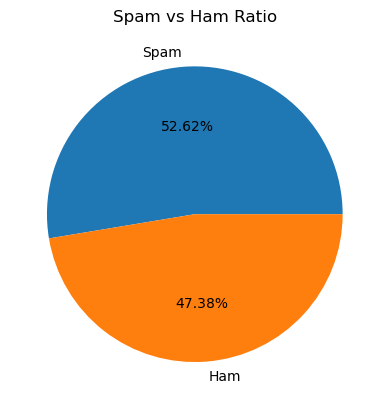

In [107]:
labels = 'Spam', 'Ham'
size = [43910, 39538]

plt.pie(size, labels=labels, autopct='%.2f%%')
plt.title('Spam vs Ham Ratio')
plt.show()

There is a good ratio of spam versus ham, which should be useful for the modeling phase

In [108]:
df.isna().sum()

label    0
text     0
dtype: int64

In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
# example of an email/message
df['text'][3]

'university degree obtain a prosperous future money earning power and the prestige that comes with having the career position you\x92ve always dreamed of diploma from prestigious non accredited unversities based on your present knowledge and professional experience if you qualify no required tests classes books or examinations confidentiality assured escapenumber escapenumber escapenumber escapenumber escapenumber hours a day escapenumber days a week including sundays and holidays sun escapenumber jun escapenumber escapenumber escapenumber escapenumber escapenumbershall borrowfor you have '

# Preprocessing

Create a function to clean each email

In [111]:
def clean_emails(doc):
    document = re.sub('[^a-zA-Z]',' ',doc)
    document = re.sub(r'\s+[a-zA-Z]\s+', ' ', document)
    document = re.sub(r'\s+', ' ', document)
    return document

In [112]:
df['cleaned_text'] = df['text'].apply(clean_emails)

In [113]:
X = df['cleaned_text']
y = df['label']

# Train Test Split

Don't need to stratify because there 53%-47% for spam versus ham is a good ratio

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Modeling 

# Naive Bayes

In [90]:
model_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

In [91]:
param_grid = {
    'tfidf__max_features':[5000,7000,9000],
    'tfidf__ngram_range':[(1,1), (1,2)],
    'nb__alpha':[0.1,0.5,1.0,2.0]
}
grid_search = GridSearchCV(
    model_pipe,
    param_grid,
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'nb__alpha': 0.1, 'tfidf__max_features': 9000, 'tfidf__ngram_range': (1, 2)}
0.9698762508730369


In [92]:
best_model_nb = grid_search.best_estimator_
best_model_nb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('nb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [96]:
preds = best_model_nb.predict(X_test)

In [97]:
print('Accuracy score: ', accuracy_score(y_test, preds))

Accuracy score:  0.9686638705811863


In [98]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7941
           1       0.98      0.96      0.97      8749

    accuracy                           0.97     16690
   macro avg       0.97      0.97      0.97     16690
weighted avg       0.97      0.97      0.97     16690



In [99]:
cm_nb = confusion_matrix(y_test, preds)

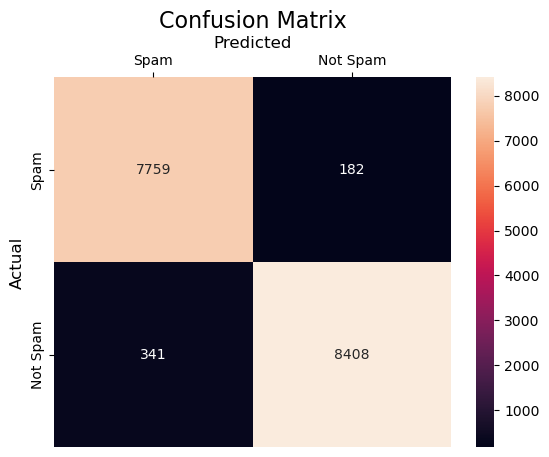

In [100]:
sns.heatmap(cm_nb, 
            annot=True, 
            fmt='g', 
            xticklabels=['Spam','Not Spam'], 
            yticklabels=['Spam','Not Spam'],
            )
plt.ylabel('Actual',fontsize=12)
plt.xlabel('Predicted',fontsize=12)
plt.title('Confusion Matrix',fontsize=16)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.show()

# SVM

In [26]:
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', LinearSVC())
])

In [27]:
svm_param_grid = {
    'tfidf__max_features':[5000,7000,9000],
    'tfidf__ngram_range':[(1,1), (1,2)],
    'svm__C':[0.1,1,5]
}

In [28]:
svm_grid_search = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=3,
    n_jobs=-1
)
svm_grid_search.fit(X_train, y_train)
print(svm_grid_search.best_params_)
print(svm_grid_search.best_score_)

{'svm__C': 1, 'tfidf__max_features': 9000, 'tfidf__ngram_range': (1, 1)}
0.9856496642227812


In [29]:
best_svm = svm_grid_search.best_estimator_
best_svm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [30]:
svm_preds = best_svm.predict(X_test)

In [31]:
print('Accuracy score: ', accuracy_score(y_test, svm_preds))

Accuracy score:  0.9852007189934092


In [32]:
print(classification_report(y_test, svm_preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7941
           1       0.98      0.99      0.99      8749

    accuracy                           0.99     16690
   macro avg       0.99      0.98      0.99     16690
weighted avg       0.99      0.99      0.99     16690



In [55]:
cm = confusion_matrix(y_test, svm_preds)

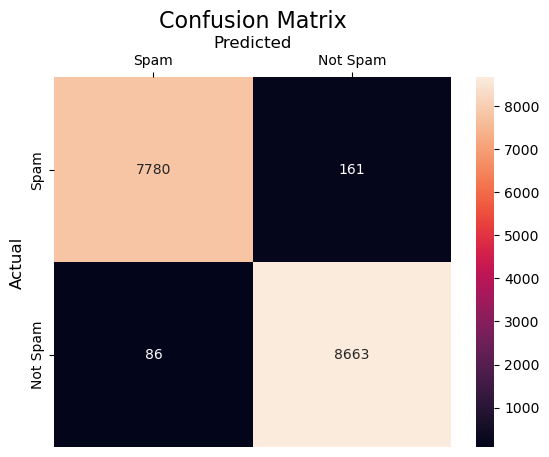

In [60]:
sns.heatmap(cm, 
            annot=True, 
            fmt='g', 
            xticklabels=['Spam','Not Spam'], 
            yticklabels=['Spam','Not Spam'],
            )
plt.ylabel('Actual',fontsize=12)
plt.xlabel('Predicted',fontsize=12)
plt.title('Confusion Matrix',fontsize=16)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.show()

In [51]:
# example
print(X_test[24021])
print(y_test[24021])

would you li ke to earn day using ebay and the internet you have received this mail for our free book secret of ebay powerseller because you expressed an interest in making money with ebay and or on the internet absolutely guarantee you have ne ver heard of this ebay internet money making system before this free no strings attached book secrets of ebay powersellers is so powerful so compelling it will blow your mind click here to start your jou rney towards financial freedom may th mark monday the eb ay millionaire in just few minutes reading my book you will find an opportunity so powerful so compelling that you ll wonder why someone hasn thought of this sooner this is not multi level marketing program or get rich quick scheme it is real business that can make you rea lly wealthy you are about to journey to wonderful pla ce place where freedom from boss making you own rules and deciding your own destiny are par amount place that offers freedom with your time and r elief from the to st

In [54]:
# example prediction
print(best_svm.predict([X_test[24021]]))

[1]


# Logistic Regression

In [63]:
logit_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('logit', LogisticRegression())
])

In [64]:
logit_param_grid = {
    'tfidf__max_features':[5000,7000,9000],
    'tfidf__ngram_range':[(1,1), (1,2)],
    'logit__C':[0.1,1,5]
}

In [66]:
logit_grid_search = GridSearchCV(
    logit_pipe,
    logit_param_grid,
    cv = 3,
    n_jobs = -1
)
logit_grid_search.fit(X_train, y_train)
print(logit_grid_search.best_params_)
print(logit_grid_search.best_score_)

{'logit__C': 5, 'tfidf__max_features': 9000, 'tfidf__ngram_range': (1, 1)}
0.9851852945669171


In [67]:
best_logit = logit_grid_search.best_estimator_
best_logit

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [68]:
logit_preds = best_logit.predict(X_test)

In [69]:
print('Accuracy score: ', accuracy_score(y_test, logit_preds))

Accuracy score:  0.983762732174955


In [70]:
print(classification_report(y_test, logit_preds))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7941
           1       0.98      0.99      0.98      8749

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



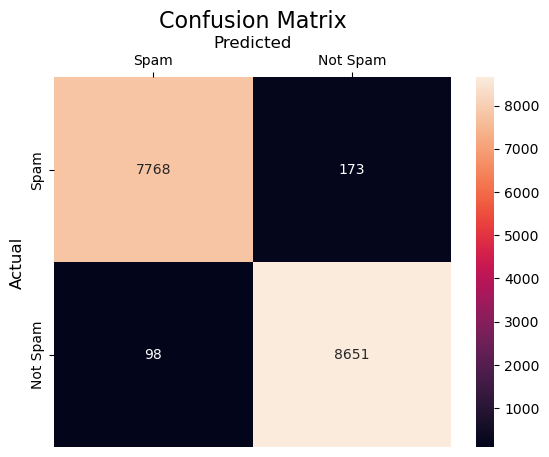

In [71]:
cm_logit = confusion_matrix(y_test, logit_preds)
sns.heatmap(cm_logit, 
            annot=True, 
            fmt='g', 
            xticklabels=['Spam','Not Spam'], 
            yticklabels=['Spam','Not Spam'],
            )
plt.ylabel('Actual',fontsize=12)
plt.xlabel('Predicted',fontsize=12)
plt.title('Confusion Matrix',fontsize=16)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.show()

# Best Model - SVM

In [132]:
model_scores = {
    'model':['Naive Bayes','SVM','Logistic Regression'],
    'accuracy':[0.968,0.985,0.983]
}
models_eval = pd.DataFrame(model_scores)

[]

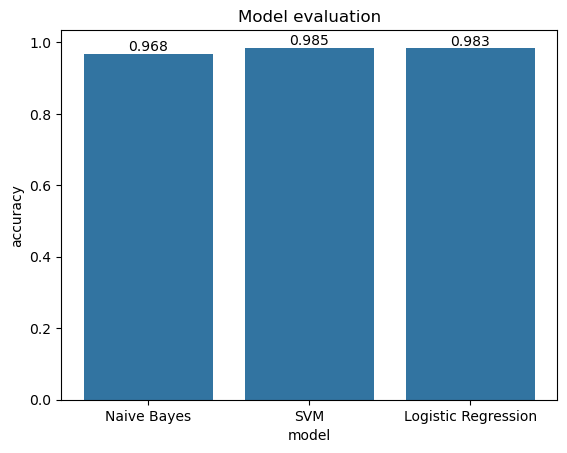

In [138]:
ax = sns.barplot(data=models_eval,x='model',y='accuracy')
plt.title('Model evaluation')
ax.bar_label(ax.containers[0])
plt.plot()

The best model was our LinearSVC model, with an accuracy of 98.5%. It also had the least amount of false negatives (161) compared to Naive Bayes (182) and Logistic Regression (173), which is what is most dangerous for a spam detector, since it tells the user it is not spam but actually is. We will save this model to load up in our app.py file 

In [72]:
dump(best_svm, 'best_model.pkl')

['best_model.pkl']

Load up the model and show some example messages/emails to test our model

In [73]:
saved_model = load('best_model.pkl')

In [118]:
new_mails = np.array(['Hello you won a lottery, click here to get your cash!',
                      'For lunch tomorrow do you want italian?',
                      'In need of a job?',
                      'If you want free money from my website all you have to do is click on the link it is super fast and easy',
                      'Reminding you to join the zoom call tomorrow at 9am'])
saved_model.predict(new_mails)

array([1, 0, 1, 1, 0])

Curious to see the most common words for spam emails versus ham emails

From our vectorizer we can get our feature names and from the classifier we can get the weights of the feature names

In [81]:
vectorizer = best_svm.named_steps['tfidf']
classifier = best_svm.named_steps['svm']

In [82]:
feature_names = vectorizer.get_feature_names_out()
weights = classifier.coef_[0]

Let's see what the top spam words are and the top ham words

In [127]:
classifier.classes_

array([0, 1])

so after sorting the weights the words with the most weight for spam would be the last 10, and the first 10 would be the least weights for ham

In [85]:
top_spam = np.argsort(weights)[-10:]
top_not_spam = np.argsort(weights)[:10]

In [88]:
print([feature_names[i] for i in top_spam])

['investment', 'whats', 'recipients', 'adf', 'qmail', 'freebsd', 'producttestpanel', 'remove', 'hk', 'gnitpick']


In [89]:
print([feature_names[i] for i in top_not_spam])

['enron', 'wrote', 'perl', 'debian', 'samba', 'vince', 'thanks', 'louise', 'ethz', 'speakup']
